# Notebook 03 — Rubber Band Segmentation & Edge Detection

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 3:** Intensity-based segmentation → clean binary mask → Canny on mask edges

**Input:** Rectified preprocessed images from `outputs/02_rectified/`  
**Output:** Binary edge maps saved to `outputs/03_canny/`

**Key idea:** The images from NB02 are already grayscale and rectified.
We apply an intensity threshold to separate the dark rubber band from the
white background, producing a clean binary mask. Canny is then applied on
that mask — not the raw image — so it only detects the outer contours of
the rubber band, eliminating internal texture noise entirely.

## 1. Imports and configuration

In [11]:
!pip install opencv-python numpy matplotlib

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [13]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")   # input from NB02
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"
OUTPUT_DIR    = Path("outputs/03_canny")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Segmentation parameters ────────────────────────────────────────────────
# The images from NB02 are already blurred and grayscale — no extra blur needed.
# Intensity threshold: pixels below = rubber (dark), above = background (light)
# None = automatic Otsu, or set a fixed int (e.g. 100) for manual control
INTENSITY_THR     = None   # None = automatic Otsu

# Morphological closing: fills small holes inside the rubber mask
# Increase if the mask has gaps; decrease if it merges separate bands
MORPH_KERNEL_SIZE = 5

# ── Canny parameters ───────────────────────────────────────────────────────
# Fixed thresholds work well here because the input is already a binary mask
CANNY_T_LOW  = 50
CANNY_T_HIGH = 150

# Load calibration from NB02
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Rectified dir  : {RECTIFIED_DIR.resolve()}")
print(f"Output dir     : {OUTPUT_DIR.resolve()}")
print(f"Calibrated imgs: {len(calibration_data)}")

Rectified dir  : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Output dir     : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Calibrated imgs: 20


## 2. Intensity-based rubber band segmentation

The images arriving from NB02 are already grayscale and blurred (NB01 applied
CLAHE + Gaussian blur, NB02 rectified them). We only need to threshold and
apply morphological closing to get a clean rubber band mask.

In [14]:
def segment_rubber_band(img_gray: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Segment the rubber band from the background using intensity thresholding.
    Input is already a grayscale blurred image from NB02.

    Returns
    -------
    mask : np.ndarray — binary mask (255 = rubber, 0 = background)
    thr  : float — threshold value used
    """
    if INTENSITY_THR is None:
        thr, mask = cv2.threshold(img_gray, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        thr = float(INTENSITY_THR)
        _, mask = cv2.threshold(img_gray, INTENSITY_THR, 255, cv2.THRESH_BINARY)

    # Invert: rubber is dark so we want dark pixels = 255
    mask = cv2.bitwise_not(mask)

    # Morphological closing: fill small holes in the rubber mask
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask, float(thr)

## 3. Canny on the clean mask

In [15]:
def detect_edges(mask: np.ndarray) -> np.ndarray:
    """
    Apply Canny on the binary rubber band mask.
    Since the mask is already binary, fixed thresholds work well.
    """
    return cv2.Canny(mask, CANNY_T_LOW, CANNY_T_HIGH)

## 4. Full pipeline per image

In [16]:
def process_image(image_name: str) -> dict | None:
    # Load rectified grayscale image from NB02
    img_gray = cv2.imread(str(RECTIFIED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"  [SKIP] {image_name}")
        return None

    mask, thr = segment_rubber_band(img_gray)
    edges     = detect_edges(mask)

    # Save edge map for NB04
    cv2.imwrite(str(OUTPUT_DIR / image_name), edges)

    return {
        'image_name'   : image_name,
        'threshold'    : thr,
        'mask_coverage': float(np.mean(mask > 0)),
        'edge_density' : float(np.mean(edges > 0))
    }

In [17]:
canny_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        canny_results[image_name] = result
        print(f"  [OK] {image_name:30s}  "
              f"thr={result['threshold']:5.1f}  "
              f"mask={result['mask_coverage']:.3f}  "
              f"edge_density={result['edge_density']:.4f}")

# Save results for reference (not strictly needed by NB04 but useful for debugging)
with open(OUTPUT_DIR / "canny_results.json", "w") as f:
    json.dump(canny_results, f, indent=2)

print(f"\nProcessed {len(canny_results)} / {len(calibration_data)} images")
print(f"Edge maps saved to {OUTPUT_DIR}")

  [OK] Multimedia_31.jpg               thr=129.0  mask=0.598  edge_density=0.0067
  [OK] Multimedia_32.jpg               thr=126.0  mask=0.576  edge_density=0.0065
  [OK] Multimedia_33.jpg               thr=127.0  mask=0.599  edge_density=0.0067
  [OK] Multimedia_34.jpg               thr=128.0  mask=0.580  edge_density=0.0063
  [OK] Multimedia_35.jpg               thr=126.0  mask=0.598  edge_density=0.0071
  [OK] Multimedia_36.jpg               thr=126.0  mask=0.598  edge_density=0.0071
  [OK] Multimedia_37.jpg               thr=127.0  mask=0.588  edge_density=0.0074
  [OK] Multimedia_39.jpg               thr=127.0  mask=0.583  edge_density=0.0064
  [OK] Multimedia_40.jpg               thr=129.0  mask=0.592  edge_density=0.0064
  [OK] Multimedia_41.jpg               thr=170.0  mask=0.587  edge_density=0.0067
  [OK] Multimedia_42.jpg               thr=129.0  mask=0.621  edge_density=0.0061
  [OK] Multimedia_43.jpg               thr=129.0  mask=0.588  edge_density=0.0061
  [OK] Multimedi

## 5. Visual inspection

Shows 3 stages: rectified input → rubber mask → edge map

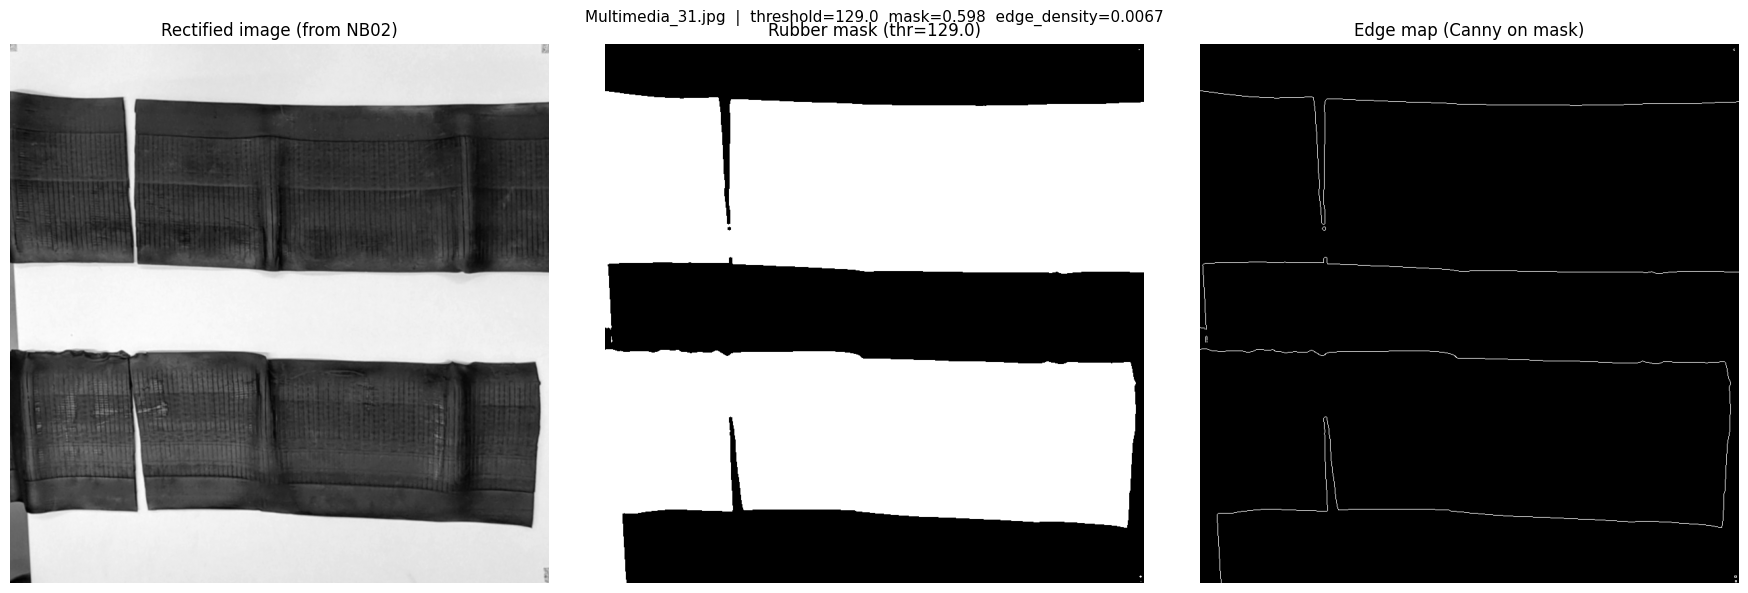

In [18]:
def visualize(image_name: str):
    img_gray      = cv2.imread(str(RECTIFIED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    mask, thr     = segment_rubber_band(img_gray)
    edges         = detect_edges(mask)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{image_name}  |  threshold={thr:.1f}  "
                 f"mask={np.mean(mask>0):.3f}  "
                 f"edge_density={np.mean(edges>0):.4f}", fontsize=11)

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title("Rectified image (from NB02)")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f"Rubber mask (thr={thr:.1f})")
    axes[1].axis('off')

    axes[2].imshow(edges, cmap='gray')
    axes[2].set_title("Edge map (Canny on mask)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


if canny_results:
    visualize(next(iter(canny_results)))

In [19]:
# Visualize a specific image
# visualize("Multimedia_42.jpg")

## 6. Diagnostics across all images

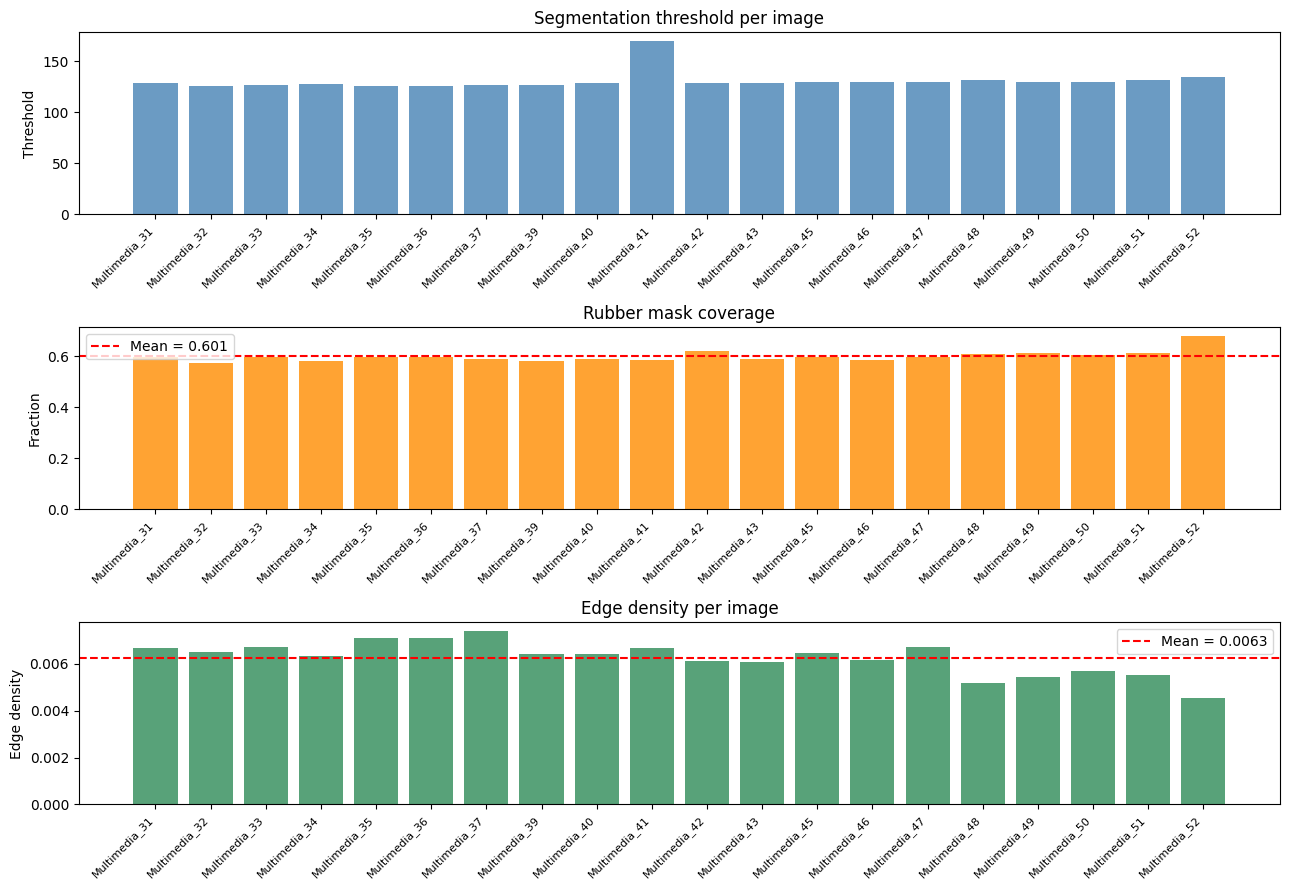

In [20]:
names     = list(canny_results.keys())
thrs      = [canny_results[n]['threshold']     for n in names]
coverages = [canny_results[n]['mask_coverage'] for n in names]
densities = [canny_results[n]['edge_density']  for n in names]
x         = range(len(names))
xlabels   = [n.replace('.jpg', '') for n in names]

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].bar(x, thrs, color='steelblue', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Threshold'); axes[0].set_title('Segmentation threshold per image')

axes[1].bar(x, coverages, color='darkorange', alpha=0.8)
axes[1].axhline(np.mean(coverages), color='red', linestyle='--',
                label=f'Mean = {np.mean(coverages):.3f}')
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Fraction'); axes[1].set_title('Rubber mask coverage')
axes[1].legend()

axes[2].bar(x, densities, color='seagreen', alpha=0.8)
axes[2].axhline(np.mean(densities), color='red', linestyle='--',
                label=f'Mean = {np.mean(densities):.4f}')
axes[2].set_xticks(x); axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Edge density'); axes[2].set_title('Edge density per image')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentation_diagnostics.png', dpi=150)
plt.show()

## 7. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 3a | Read rectified image | from `outputs/02_rectified/` (already grayscale + blurred) |
| 3b | Intensity threshold | Otsu automatic (inverted: rubber = 255) |
| 3c | Morphological closing | ellipse kernel 5×5 |
| 3d | Canny on mask | t_low=50, t_high=150 |

**Tuning tips:**
- Mask includes too much background → lower `INTENSITY_THR` manually
- Mask has holes inside rubber → increase `MORPH_KERNEL_SIZE`
- Mask merges both bands → decrease `MORPH_KERNEL_SIZE`

**Output folder:** `outputs/03_canny/`  
**Used by:** NB04  
**Next notebook:** `04_hough.ipynb` — reads from `outputs/03_canny/`